In [ ]:
#Goal -- Identify the hidden group/categories in the dataset.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("Mall_Customers.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


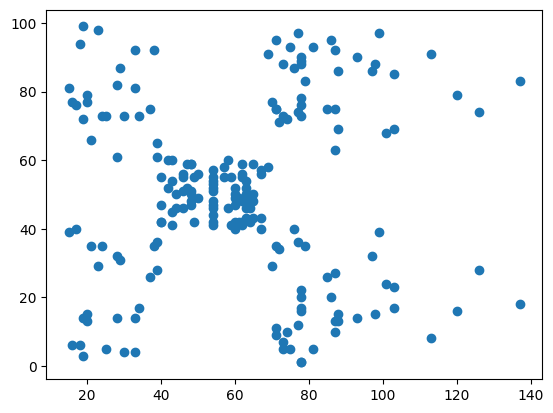

In [ ]:
#Goal: Perform Customer Segmentation (Customer Grouping) for Annual Income and Spending Score
import matplotlib.pyplot as plt
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])

In [ ]:
#Use Clustering Method to
# 1. Identify how many groups are possible
# 2. Which datapoints belong to which group

In [ ]:
features = data.iloc[:,[3,4]].values

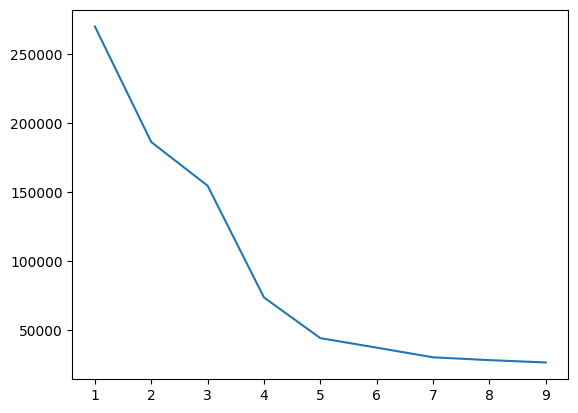

In [ ]:
# 1. Identify how many groups are possible

# The ELBOW Method --- WCSS (Within Cluster Sum of Squares)

from sklearn.cluster import KMeans

wcss=[]

for category in range(1,10):
  model = KMeans(n_clusters=category, random_state=1)
  model.fit(features)
  wcss.append(model.inertia_)

plt.plot(range(1,10), wcss)

In [ ]:
#Model Building

finalModel5Clusters = KMeans(n_clusters=5)
finalModel5Clusters.fit(features)

KMeans(n_clusters=5)

In [ ]:
#Reveal the labels --- This predicts which datapoint belongs to which group
labels = finalModel5Clusters.predict(features)

In [ ]:
labels

array([3, 2, 3, 2, 3, 2, 3, 0, 3, 2, 3, 0, 3, 2, 3, 2, 3, 2, 3, 0, 3, 2,
       3, 2, 3, 0, 3, 2, 3, 0, 3, 2, 3, 0, 3, 0, 3, 2, 3, 2, 3, 0, 2, 2,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

/tmp/ipython-input-4141253333.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finalDataset['predlabel']=labels


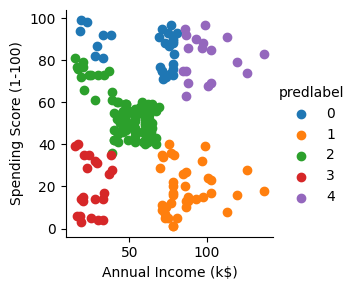

In [ ]:
finalDataset = data.iloc[:,[3,4]]
finalDataset['predlabel']=labels

import seaborn as sns
sns.FacetGrid(finalDataset, hue='predlabel').map(plt.scatter, 'Annual Income (k$)' , 'Spending Score (1-100)').add_legend()

In [ ]:
#Model Building

finalModel5Clusters = KMeans(n_clusters=5)
finalModel5Clusters.fit(features)

KMeans(n_clusters=5)

In [ ]:
#Reveal the labels
labels = finalModel5Clusters.predict(features)

In [ ]:
labels

array([4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 3,
       4, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 0, 2, 3, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 3, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int32)

<ipython-input-27-d53167183c4a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finalDataset['predlabel']=labels


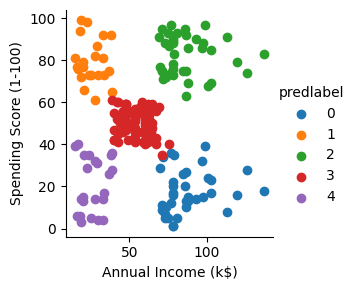

In [ ]:
finalDataset = data.iloc[:,[3,4]]
finalDataset['predlabel']=labels

import seaborn as sns
sns.FacetGrid(finalDataset, hue='predlabel').map(plt.scatter, 'Annual Income (k$)' , 'Spending Score (1-100)').add_legend()

In [ ]:
finalModel5Clusters.predict(np.array([[9000,80]]))

array([0], dtype=int32)

In [ ]:
# Age vs Spending Score